# U-Net Inference on test_data (10-Band + Indices Contract)

Loads `best_unet_10b.pth` and runs pixel-wise inference on `test_data` with the same metric outputs used in the RF inference notebook.

Input feature contract: `B2,B3,B4,B5,B6,B7,B8,B8A,B11,B12,NDVI,NDBI,MNDWI,BSI,DBI,NSI`.

In [ ]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm

import torch
import torch.nn as nn

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings('ignore')

PROJECT_DIR = Path(r'c:/satellite/project')
TEST_DATA_DIR = PROJECT_DIR / 'data/test_data'
MODEL_PATH = PROJECT_DIR / 'best_unet_10b_v1.pth'

DEFAULT_CLASS_NAMES = {1: 'Greenery', 2: 'Sand', 3: 'Water', 4: 'Cement'}
CLASS_COLORS = {1: 'darkgreen', 2: 'gold', 3: 'navy', 4: 'gray'}
CLASS_NAMES = DEFAULT_CLASS_NAMES
CLASS_IDS = sorted(CLASS_NAMES.keys())
ACTIVE_CLASSES = CLASS_IDS
EPS = 1e-6

# Postprocessing config (majority-vote smoothing on predicted labels)
POSTPROCESS_ENABLE = False
POSTPROCESS_WINDOW = 3

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)
print(f'Postprocessing enabled: {POSTPROCESS_ENABLE} | window={POSTPROCESS_WINDOW}')

Device: cuda
Postprocessing enabled: False | window=3


In [136]:
import torch.nn.functional as F

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

class UNetSmall(nn.Module):
    def __init__(self, in_ch=10, n_classes=5, base=32):
        super().__init__()
        self.enc1 = ConvBlock(in_ch, base)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = ConvBlock(base, base*2)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = ConvBlock(base*2, base*4)
        self.pool3 = nn.MaxPool2d(2)
        self.bottleneck = ConvBlock(base*4, base*8)
        self.up3 = nn.ConvTranspose2d(base*8, base*4, 2, 2)
        self.dec3 = ConvBlock(base*8, base*4)
        self.up2 = nn.ConvTranspose2d(base*4, base*2, 2, 2)
        self.dec2 = ConvBlock(base*4, base*2)
        self.up1 = nn.ConvTranspose2d(base*2, base, 2, 2)
        self.dec1 = ConvBlock(base*2, base)
        self.outc = nn.Conv2d(base, n_classes, kernel_size=1)

    def _align_skip(self, skip, target):
        # Handle odd-size inputs where pooling/upsampling creates 1-pixel mismatches.
        if skip.shape[-2:] != target.shape[-2:]:
            skip = F.interpolate(skip, size=target.shape[-2:], mode='bilinear', align_corners=False)
        return skip

    def forward(self, x):
        input_hw = x.shape[-2:]

        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        b = self.bottleneck(self.pool3(e3))

        d3 = self.up3(b)
        e3 = self._align_skip(e3, d3)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.up2(d3)
        e2 = self._align_skip(e2, d2)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        e1 = self._align_skip(e1, d1)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        out = self.outc(d1)
        if out.shape[-2:] != input_hw:
            out = F.interpolate(out, size=input_hw, mode='bilinear', align_corners=False)
        return out

ckpt = torch.load(MODEL_PATH, map_location=DEVICE)
model = UNetSmall(in_ch=ckpt.get('in_channels', 10), n_classes=ckpt.get('num_classes', 5), base=32).to(DEVICE)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

CLASS_NAMES = ckpt.get('class_names', CLASS_NAMES)
CLASS_IDS = sorted(CLASS_NAMES.keys())
ACTIVE_CLASSES = CLASS_IDS

print('Loaded model:', ckpt.get('model_type', 'unet_small'))
print('Feature names:', ckpt.get('feature_names', []))
print('Classes:', CLASS_NAMES)

Loaded model: unet_small
Feature names: ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']
Classes: {1: 'Greenery', 2: 'Sand', 3: 'Water', 4: 'Cement'}


In [137]:
spectral_files = sorted(TEST_DATA_DIR.glob('*_Spectral*.tif'))
mask_files = sorted(TEST_DATA_DIR.glob('*_Mask*.tif'))

def pair_id(path: Path) -> str:
    name = path.name
    name = name.replace('_Spectral_12B.tif', '')
    name = name.replace('_Spectral.tif', '')
    name = name.replace('_Mask_Class.tif', '')
    name = name.replace('_Mask.tif', '')
    return name

spectral_lookup = {pair_id(path): path for path in spectral_files}
mask_lookup = {pair_id(path): path for path in mask_files}
common_ids = sorted(set(spectral_lookup) & set(mask_lookup))
sample_pairs = [
    {'name': site_id, 'spectral_path': spectral_lookup[site_id], 'mask_path': mask_lookup[site_id]}
    for site_id in common_ids
]

print('Paired test samples:', [x['name'] for x in sample_pairs])
print('Unmatched spectral files:', len(set(spectral_lookup)-set(mask_lookup)))
print('Unmatched mask files:', len(set(mask_lookup)-set(spectral_lookup)))

Paired test samples: ['CairoUniv', 'HawaraFayoum', 'IconicTower', 'KarnakLuxor', 'PhilaeAswan', 'SiwaOasis']
Unmatched spectral files: 0
Unmatched mask files: 0


In [138]:
# test_data band order: B1,B2,B3,B4,B5,B6,B7,B8,B8A,B9,B11,B12
IDX_B2, IDX_B3, IDX_B4 = 1, 2, 3
IDX_B5, IDX_B6, IDX_B7 = 4, 5, 6
IDX_B8, IDX_B8A, IDX_B11, IDX_B12 = 7, 8, 10, 11

def normalize_spectral_10_from_test(cube12: np.ndarray) -> np.ndarray:
    x = np.stack([
        cube12[IDX_B2], cube12[IDX_B3], cube12[IDX_B4], cube12[IDX_B5], cube12[IDX_B6],
        cube12[IDX_B7], cube12[IDX_B8], cube12[IDX_B8A], cube12[IDX_B11], cube12[IDX_B12]
    ], axis=0).astype(np.float32)
    probe = np.nanpercentile(x, 99)
    if probe > 2.0:
        x = np.clip(x / 10000.0, 0.0, 1.0)
    else:
        x = np.clip(x, 0.0, 1.0)
    return x

def compute_spectral_indices(spectral_norm: np.ndarray) -> np.ndarray:
    # spectral_norm order: B2,B3,B4,B5,B6,B7,B8,B8A,B11,B12
    b2 = spectral_norm[0]
    b3 = spectral_norm[1]
    b4 = spectral_norm[2]
    b8 = spectral_norm[6]
    b8a = spectral_norm[7]
    b11 = spectral_norm[8]

    ndvi = (b8 - b4) / (b8 + b4 + EPS)
    ndbi = (b11 - b8) / (b11 + b8 + EPS)
    mndwi = (b3 - b11) / (b3 + b11 + EPS)
    bsi = ((b11 + b4) - (b8 + b2)) / ((b11 + b4) + (b8 + b2) + EPS)
    dbi = ndbi - ndvi
    nsi = (b11 - b8a) / (b11 + b8a + EPS)

    return np.stack([ndvi, ndbi, mndwi, bsi, dbi, nsi], axis=0).astype(np.float32)

def build_unet_features_from_test(cube12: np.ndarray) -> np.ndarray:
    spectral_norm = normalize_spectral_10_from_test(cube12)  # (10, H, W)
    indices = compute_spectral_indices(spectral_norm)        # (6, H, W)
    return np.concatenate([spectral_norm], axis=0).astype(np.float32)  # (16, H, W)

def compute_per_class_iou(y_true: np.ndarray, y_pred: np.ndarray, class_ids):
    ious = {}
    for class_id in class_ids:
        inter = np.sum((y_true == class_id) & (y_pred == class_id))
        union = np.sum((y_true == class_id) | (y_pred == class_id))
        ious[class_id] = inter / union if union > 0 else np.nan
    return ious

def majority_vote_smoothing(label_map: np.ndarray, class_ids, window: int = 3) -> np.ndarray:
    if window <= 1:
        return label_map
    if window % 2 == 0:
        raise ValueError('POSTPROCESS_WINDOW must be odd for centered voting.')

    pad = window // 2
    padded = np.pad(label_map, ((pad, pad), (pad, pad)), mode='reflect')
    patches = np.lib.stride_tricks.sliding_window_view(padded, (window, window))

    class_ids = np.array(class_ids, dtype=np.int32)
    vote_counts = np.stack([
        np.sum(patches == class_id, axis=(-1, -2))
        for class_id in class_ids
    ], axis=-1)

    winners = np.argmax(vote_counts, axis=-1)
    return class_ids[winners].astype(label_map.dtype)

def make_rgb(spectral_cube: np.ndarray) -> np.ndarray:
    red = spectral_cube[IDX_B4].astype(np.float32)
    green = spectral_cube[IDX_B3].astype(np.float32)
    blue = spectral_cube[IDX_B2].astype(np.float32)
    rgb = np.stack([red, green, blue], axis=-1)
    p2, p98 = np.percentile(rgb, [2, 98])
    return np.clip((rgb - p2) / (p98 - p2 + EPS), 0, 1)

cmap_cls = ListedColormap([CLASS_COLORS[c] for c in CLASS_IDS])
bounds = np.arange(min(CLASS_IDS)-0.5, max(CLASS_IDS)+1.5, 1)
norm_cls = BoundaryNorm(bounds, ncolors=len(CLASS_IDS))
legend_patches = [mpatches.Patch(color=CLASS_COLORS[c], label=f'{c}: {CLASS_NAMES[c]}') for c in CLASS_IDS]

In [139]:
records = []
predictions_by_site = {}

expected_in_channels = int(ckpt.get('in_channels', 10))

with torch.no_grad():
    for sample_item in sample_pairs:
        sample_name = sample_item['name']

        with rasterio.open(sample_item['spectral_path']) as src:
            spectral_cube = src.read().astype(np.float32)

        with rasterio.open(sample_item['mask_path']) as src:
            y_true = src.read(1).astype(np.int32)

        x = build_unet_features_from_test(spectral_cube)
        if x.shape[0] != expected_in_channels:
            raise ValueError(
                f"Feature-channel mismatch for {sample_name}: built {x.shape[0]} but model expects {expected_in_channels}. "
                "Retrain model or align feature contract."
            )

        xb = torch.from_numpy(x).unsqueeze(0).to(DEVICE)
        logits = model(xb)
        y_pred_raw = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy().astype(np.int32)

        if POSTPROCESS_ENABLE:
            y_pred = majority_vote_smoothing(y_pred_raw, CLASS_IDS, window=POSTPROCESS_WINDOW)
        else:
            y_pred = y_pred_raw

        valid_mask = y_true != 0
        y_true_valid = y_true[valid_mask]
        y_pred_valid = y_pred[valid_mask]

        ious = compute_per_class_iou(y_true_valid, y_pred_valid, ACTIVE_CLASSES)
        miou = float(np.nanmean([ious[c] for c in ACTIVE_CLASSES]))
        accuracy = float(np.mean(y_true_valid == y_pred_valid))

        row = {'sample': sample_name, 'accuracy': accuracy, 'mIoU_active': miou}
        for class_id in ACTIVE_CLASSES:
            row[f'IoU_{CLASS_NAMES[class_id]}'] = ious[class_id]
        records.append(row)

        predictions_by_site[sample_name] = {
            'spectral_cube': spectral_cube,
            'y_true': y_true,
            'y_true_valid': y_true_valid,
            'y_pred_raw': y_pred_raw,
            'y_pred': y_pred,
            'y_pred_valid': y_pred_valid
        }

metrics_df = pd.DataFrame(records).sort_values('mIoU_active', ascending=False).reset_index(drop=True)
metrics_df

,sample,accuracy,mIoU_active,IoU_Greenery,IoU_Sand,IoU_Water,IoU_Cement
0,KarnakLuxor,0.881609,0.751641,0.741042,0.537992,0.926140,0.801389
1,SiwaOasis,0.740583,0.652573,0.768018,0.451860,0.875784,0.514629
2,CairoUniv,0.952826,0.578705,0.355290,0.086313,0.928054,0.945162
3,HawaraFayoum,0.943724,0.572843,0.942064,0.911608,0.000000,0.437701
4,PhilaeAswan,0.776245,0.499858,0.368840,0.521307,0.917313,0.191972
5,IconicTower,0.810289,0.370730,0.239977,0.803601,0.029010,0.410333


In [140]:
print('Mean active-class mIoU:', round(metrics_df['mIoU_active'].mean(), 4))
print('Mean accuracy:', round(metrics_df['accuracy'].mean(), 4))
print(f'Postprocessing enabled: {POSTPROCESS_ENABLE} | window={POSTPROCESS_WINDOW}')
print('\nPer-sample metrics:')
for _, row in metrics_df.iterrows():
    print(f"{row['sample']:<15} mIoU={row['mIoU_active']:.4f}  acc={row['accuracy']:.4f}")

Mean active-class mIoU: 0.5711
Mean accuracy: 0.8509
Postprocessing enabled: False | window=3

Per-sample metrics:
KarnakLuxor     mIoU=0.7516  acc=0.8816
SiwaOasis       mIoU=0.6526  acc=0.7406
CairoUniv       mIoU=0.5787  acc=0.9528
HawaraFayoum    mIoU=0.5728  acc=0.9437
PhilaeAswan     mIoU=0.4999  acc=0.7762
IconicTower     mIoU=0.3707  acc=0.8103


              precision    recall  f1-score   support

    Greenery       0.91      0.88      0.89    149024
        Sand       0.85      0.81      0.83    165917
       Water       0.99      0.92      0.95     88283
      Cement       0.77      0.84      0.80    210318

    accuracy                           0.85    613542
   macro avg       0.88      0.86      0.87    613542
weighted avg       0.86      0.85      0.85    613542



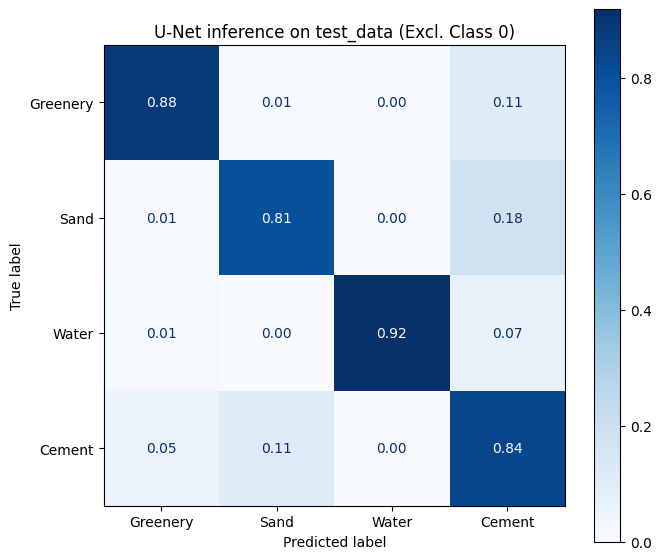

Predictions: (array([1, 2, 3, 4], dtype=int32), array([144824, 158317,  81888, 228513]))
Truth: (array([1, 2, 3, 4], dtype=int32), array([149024, 165917,  88283, 210318]))


In [141]:
all_true = np.concatenate([predictions_by_site[k]['y_true_valid'] for k in predictions_by_site])
all_pred = np.concatenate([predictions_by_site[k]['y_pred_valid'] for k in predictions_by_site])

print(classification_report(
    all_true,
    all_pred,
    labels=CLASS_IDS,
    target_names=[CLASS_NAMES[c] for c in CLASS_IDS],
    zero_division=0
))

cm = confusion_matrix(all_true, all_pred, labels=CLASS_IDS, normalize='true')
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[CLASS_NAMES[c] for c in CLASS_IDS]).plot(
    ax=ax, cmap='Blues', values_format='.2f', colorbar=True
)
ax.set_title('U-Net inference on test_data (Excl. Class 0)')
plt.tight_layout()
plt.show()

print('Predictions:', np.unique(all_pred, return_counts=True))
print('Truth:', np.unique(all_true, return_counts=True))

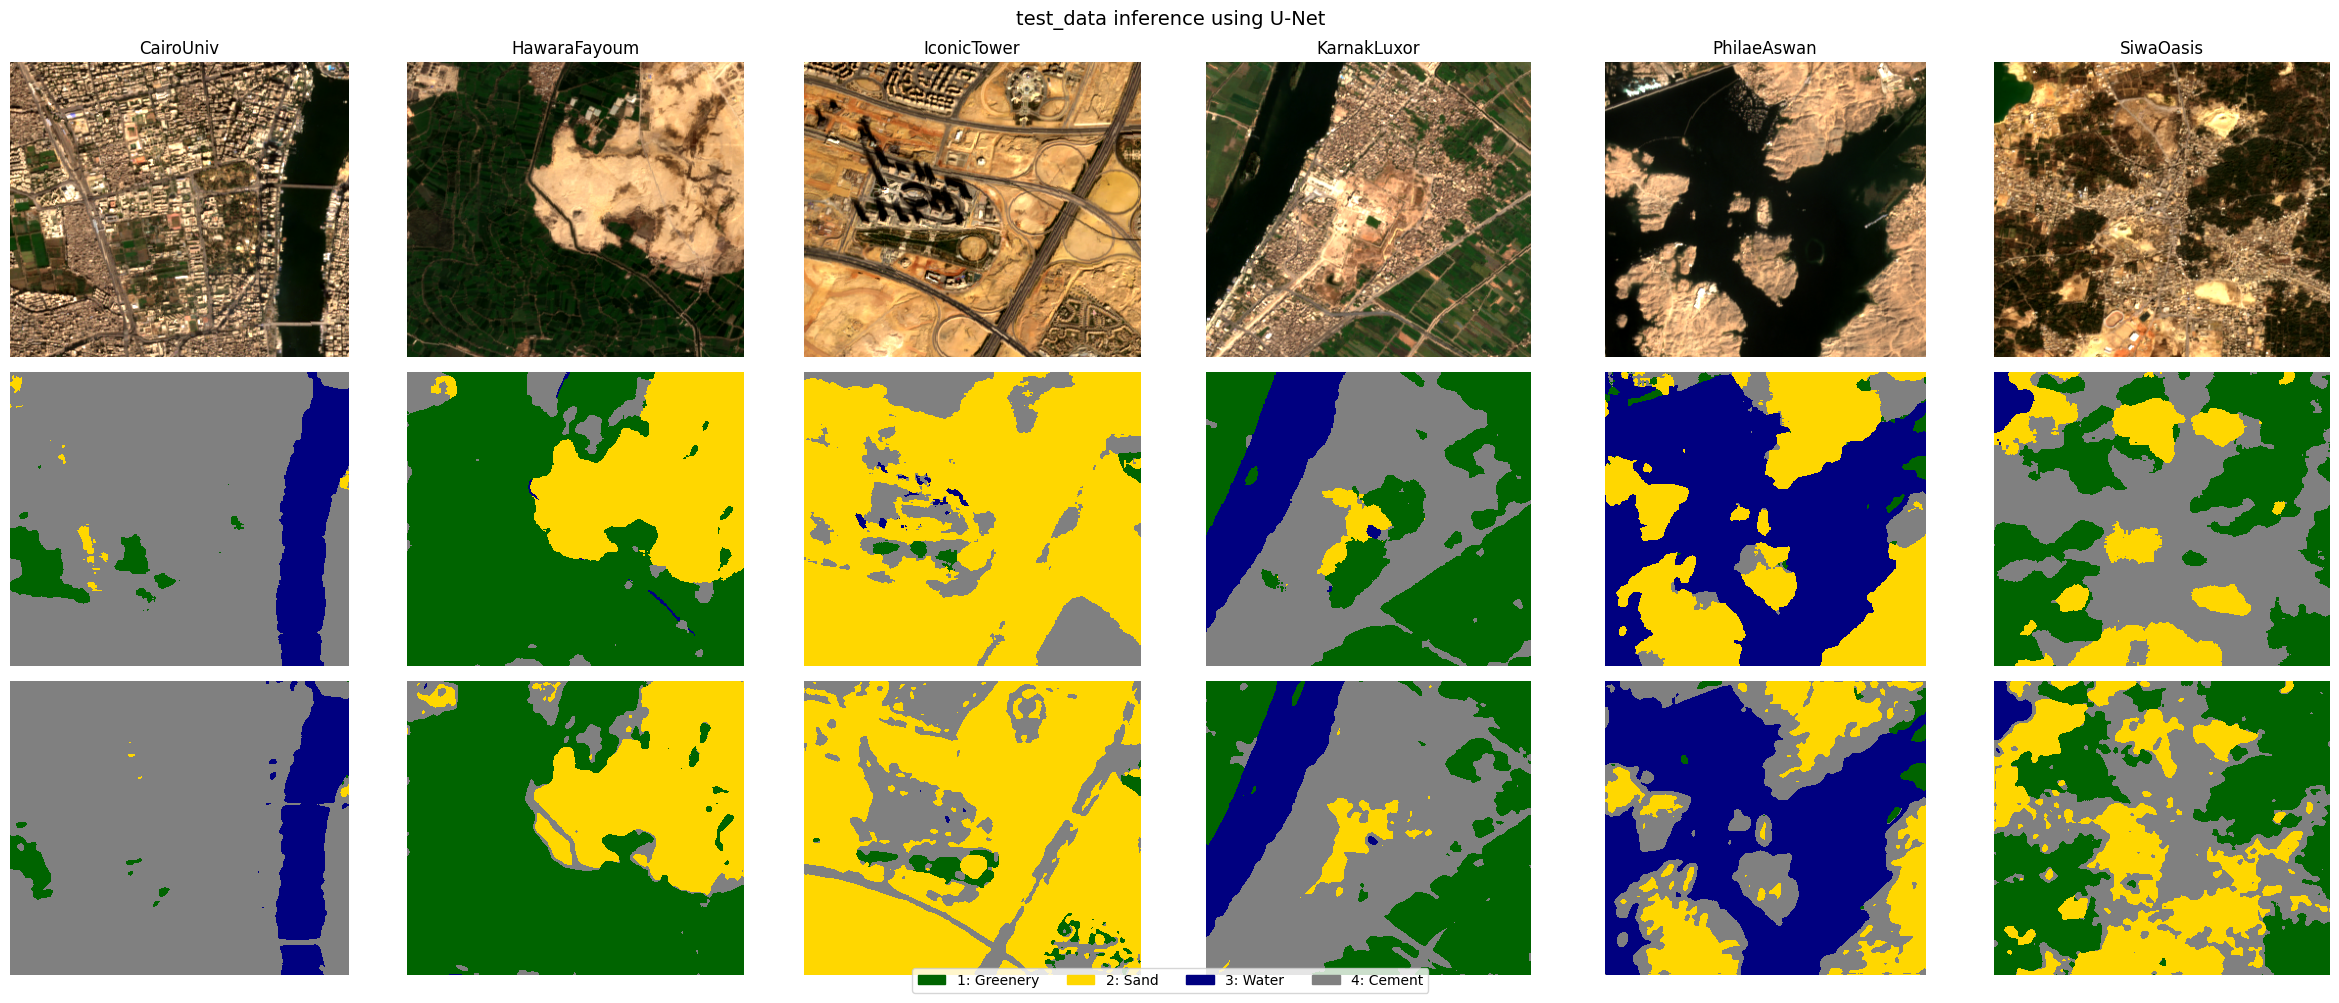

In [142]:
n_samples = len(sample_pairs)
fig, axes = plt.subplots(3, n_samples, figsize=(4*n_samples, 10))
if n_samples == 1:
    axes = np.array(axes).reshape(3, 1)

for col, sample_item in enumerate(sample_pairs):
    name = sample_item['name']
    bundle = predictions_by_site[name]
    rgb = make_rgb(bundle['spectral_cube'])

    axes[0, col].imshow(rgb)
    axes[0, col].set_title(name)
    axes[0, col].axis('off')

    axes[1, col].imshow(bundle['y_true'], cmap=cmap_cls, norm=norm_cls, interpolation='nearest')
    axes[1, col].axis('off')

    axes[2, col].imshow(bundle['y_pred'], cmap=cmap_cls, norm=norm_cls, interpolation='nearest')
    axes[2, col].axis('off')

axes[0, 0].set_ylabel('RGB', fontsize=10)
axes[1, 0].set_ylabel('Ground Truth', fontsize=10)
axes[2, 0].set_ylabel('Prediction (U-Net)', fontsize=10)

fig.legend(handles=legend_patches, loc='lower center', ncol=len(CLASS_IDS), bbox_to_anchor=(0.5, -0.01))
plt.suptitle('test_data inference using U-Net', fontsize=14)
plt.tight_layout()
plt.show()

In [143]:
metrics_path = PROJECT_DIR / 'test_data_inference_metrics_unet_10b.csv'
metrics_df.to_csv(metrics_path, index=False)
print('Saved metrics:', metrics_path)

Saved metrics: c:\satellite\project\test_data_inference_metrics_unet_10b.csv
